# 02: Double Machine Learning Basics

This lesson explains the core idea behind double machine learning in EconML: estimate the parts of treatment and outcome that are predictable from observed covariates, remove those predictable parts, and use the remaining variation to estimate causal effects.

The lesson uses a synthetic example dataset where the true treatment effect is known. That makes the workflow unusually transparent. We can see the raw observational bias, build the residualization logic by hand, then compare the manual version to `LinearDML` from EconML.

The main causal question is:

> For users with different baseline characteristics, how much would the outcome change if the treatment were applied instead of not applied?

That is a CATE question. DML is one of the most important ways EconML answers it.

## Learning Goals

By the end, you should be able to:

- explain why DML estimates nuisance functions before estimating a treatment effect;
- distinguish outcome nuisance models from treatment nuisance models;
- explain residualization in plain language;
- understand why cross-fitting reduces overfitting bias in causal estimation;
- fit a simple manual DML-style estimator;
- fit EconML's `LinearDML` on the same data;
- compare naive, manual DML, and EconML estimates against known truth;
- diagnose overlap, nuisance model quality, residualized treatment variation, and CATE recovery.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **Double Machine Learning Basics**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment uses nuisance functions for outcome and treatment assignment. The DML lesson is how orthogonalization turns those nuisance fits into a causal estimate.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Double machine learning estimates treatment effects after removing predictable parts of outcome and treatment. A partially linear CATE model can be written as

$$
Y=\theta(X)D+g_0(X)+\varepsilon.
$$

For a constant effect, the final stage is

$$
Y-\widehat g(X) \approx \theta\{D-\widehat m(X)\}.
$$

LinearDML, SparseLinearDML, and CausalForestDML differ in how they represent $\theta(X)$.



The notebook follows the DML workflow in small steps:

1. Create a confounded synthetic dataset with known heterogeneous treatment effects.
2. Show why a raw treated-versus-control comparison is biased.
3. Define which variables are treatment effect modifiers and which are controls.
4. Fit cross-fitted nuisance models for outcome and treatment.
5. Residualize outcome and treatment.
6. Estimate a manual residual-on-residual ATE.
7. Estimate a manual linear CATE model using residualized treatment interactions.
8. Fit EconML's `LinearDML`.
9. Compare the resulting CATE estimates to known truth.
10. Summarize the practical checklist for using DML responsibly.

## The Core DML Idea

DML starts from a simple concern: in observational data, treatment is usually not randomly assigned. If high-risk users are more likely to receive treatment, then a raw outcome comparison mixes two things:

- the causal effect of treatment;
- the pre-existing differences between treated and untreated users.

DML tries to remove the predictable, confounded parts first. In a partially linear setup, the observed outcome can be written as:

`Y = baseline_outcome(X, W) + treatment_effect(X) * T + noise`

and treatment assignment can be written as:

`T = propensity(X, W) + assignment_noise`

Here:

- `Y` is the observed outcome;
- `T` is treatment;
- `X` contains effect modifiers used to explain how treatment effects vary;
- `W` contains controls that help remove confounding but are not the main CATE reporting dimensions;
- the outcome nuisance model estimates `E[Y | X, W]`;
- the treatment nuisance model estimates `E[T | X, W]` or the propensity score.

After residualizing, DML asks: among users with similar predicted treatment probability and similar predicted outcome level, does the remaining treatment variation explain the remaining outcome variation?




## Tutorial Workflow

#### Setup

The code below imports the packages used in the lesson, makes output folders, fixes display options, and checks that EconML is available. The warning filters keep the notebook readable while still letting real execution errors appear.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np

# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default

    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import econml
    from econml.dml import LinearDML
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")


IPython could not be loaded!


EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/tables


The environment is ready if EconML imports successfully. The output folders are local to this tutorial folder, so the notebook can save figures and tables without mixing them with the applied causal projects.

#### Synthetic Example Data

The next cell creates data with three useful properties:

- treatment assignment is confounded because treatment depends on baseline covariates;
- treatment effects are heterogeneous because the true CATE depends on user characteristics;
- the true CATE is kept in the table only for diagnostics.

In a real dataset, `true_cate` and `propensity` are not observed. They are included here so we can check whether each estimator is learning the right object.

In [2]:
n = 3_000

baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
friction_score = 0.45 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.9, size=n)
region_risk = rng.binomial(1, 0.35, size=n)
high_need_segment = (baseline_need > 0.45).astype(int)

# Treatment is more likely for users who look needier, more engaged, or more friction-heavy.
propensity_logit = (
    -0.20
    + 0.75 * baseline_need
    + 0.45 * prior_engagement
    - 0.30 * account_tenure
    + 0.45 * friction_score
    + 0.30 * region_risk
    + 0.25 * high_need_segment
    + 0.25 * seasonality_index
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.04, 0.96)
treatment = rng.binomial(1, propensity, size=n)

# The true CATE is linear in the effect modifiers, which makes LinearDML a sensible illustrative estimator.
true_cate = (
    0.45
    + 0.28 * baseline_need
    + 0.18 * prior_engagement
    - 0.22 * friction_score
    - 0.10 * region_risk
    + 0.24 * high_need_segment
)

baseline_outcome = (
    2.00
    + 0.85 * baseline_need
    + 0.65 * prior_engagement
    - 0.45 * friction_score
    + 0.35 * account_tenure
    + 0.30 * seasonality_index
    + 0.22 * region_risk
    + 0.12 * baseline_need * friction_score
)
noise = rng.normal(0, 0.85, size=n)
outcome = baseline_outcome + true_cate * treatment + noise

teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "friction_score": friction_score,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "true_cate": true_cate,
        "baseline_outcome_mean": baseline_outcome,
    }
)

teaching_df.head()


,user_id,baseline_need,prior_engagement,account_tenure,seasonality_index,friction_score,region_risk,high_need_segment,propensity,treatment,outcome,true_cate,baseline_outcome_mean
0,0,-0.7931,-0.4520,0.3610,1.5171,1.0923,0,0,0.4413,1,1.6935,-0.0937,1.0180
1,1,0.2406,-0.3531,-1.0970,-0.6711,-1.3666,0,0,0.3470,0,2.8867,0.7544,1.9652
2,2,-1.8963,-0.9423,-0.4935,0.9219,0.2232,0,0,0.1726,0,-0.1574,-0.2997,-0.2718
3,3,1.3958,0.0110,0.4890,0.1365,0.8186,0,1,0.7954,1,4.4147,0.9027,3.1744
4,4,0.6383,1.1904,-0.5878,1.5456,-0.3600,0,1,0.8123,1,4.0839,1.1622,3.7087


Each row is one observational unit. `treatment` and `outcome` are the two fields we would definitely observe in a real analysis. The fields `propensity`, `true_cate`, and `baseline_outcome_mean` are oracle fields that help us teach and debug the DML workflow.

#### Field Dictionary

Before modeling, it helps to name every column and explain whether it is observed in a real analysis. This prevents a common tutorial mistake: accidentally training on oracle fields that would not exist outside a simulation.

| column | role | observed_in_real_analysis | description |
| --- | --- | --- | --- |
| user_id | identifier | yes | Unique row identifier. |
| baseline_need | effect modifier and confounder | yes | Baseline user need. It affects treatment assignment, baseline outcome, and treatment effect. |
| prior_engagement | effect modifier and confounder | yes | Pre-treatment engagement level. It affects treatment assignment, baseline outcome, and treatment effect. |
| account_tenure | control | yes | Pre-treatment account age signal. It affects treatment and outcome, but not the true CATE here. |
| seasonality_index | control | yes | Pre-treatment timing or seasonality signal. It helps remove confounding. |
| friction_score | effect modifier and confounder | yes | Pre-treatment friction signal. Treatment effects are smaller when friction is high. |
| region_risk | effect modifier and confounder | yes | Binary segment with different baseline outcomes and treatment effects. |
| high_need_segment | effect modifier | yes | Segment indicator derived from baseline need. |
| propensity | oracle treatment probability | no | True probability of treatment under the simulated assignment mechanism. |
| treatment | treatment | yes | Binary treatment indicator. |
| outcome | outcome | yes | Observed post-treatment outcome. |
| true_cate | oracle effect | no | Known individual treatment effect used only for tutorial evaluation. |
| baseline_outcome_mean | oracle baseline response | no | Mean untreated outcome component before random noise. |


DML should use only pre-treatment observed covariates, treatment, and outcome. Oracle fields are useful for grading the lesson, but they must not be included in the nuisance models or final CATE model.

#### Basic Shape and Treatment Rate

The next cell gives a quick dataset summary. For DML, the treatment rate matters because the method needs enough treated and untreated observations in comparable covariate regions.

In [3]:
basic_shape = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"metric": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"metric": "true_cate_std", "value": teaching_df["true_cate"].std()},
    ]
)

basic_shape.to_csv(TABLE_DIR / "02_basic_shape.csv", index=False)
display(basic_shape)


,metric,value
0,rows,"3,000.0000"
1,columns,13.0000
2,treatment_rate,0.4940
3,outcome_mean,2.4470
4,true_ate,0.4990
5,true_cate_std,0.4103


The treatment rate is neither extremely close to zero nor one, which gives us enough variation for a worked example. The true CATE standard deviation confirms that this is more than an ATE problem; effects vary meaningfully across units.

### True Estimands Available in the Simulation

Because the data is simulated, we can compute the true ATE, ATT, and ATC directly from `true_cate`.

- ATE is the average effect across everyone.
- ATT is the average effect among treated units.
- ATC is the average effect among untreated units.

If treatment assignment favors people with higher or lower treatment effects, ATT and ATC can differ from ATE.

In [4]:
true_effect_summary = pd.DataFrame(
    [
        {"estimand": "ATE", "definition": "Average true CATE over all rows", "value": teaching_df["true_cate"].mean()},
        {"estimand": "ATT", "definition": "Average true CATE among treated rows", "value": teaching_df.loc[teaching_df["treatment"].eq(1), "true_cate"].mean()},
        {"estimand": "ATC", "definition": "Average true CATE among untreated rows", "value": teaching_df.loc[teaching_df["treatment"].eq(0), "true_cate"].mean()},
    ]
)

true_effect_summary.to_csv(TABLE_DIR / "02_true_effect_summary.csv", index=False)
display(true_effect_summary)

,estimand,definition,value
0,ATE,Average true CATE over all rows,0.4990
1,ATT,Average true CATE among treated rows,0.6076
2,ATC,Average true CATE among untreated rows,0.3930


The target estimand must be named before fitting models. This lesson mainly focuses on the CATE and its average over a test set, but seeing ATE, ATT, and ATC side by side reinforces that treatment assignment changes which population is being averaged.

### Raw Observational Difference

A raw treated-versus-control comparison is tempting, but it is usually not a causal estimate. Here treatment is assigned based on covariates, so treated users are systematically different before treatment.

The next cell compares observed outcomes by treatment group and contrasts the raw difference with the true ATE.

In [5]:
# Save the artifacts produced by the Raw Observational Difference section.
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        observed_outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        prior_engagement_mean=("prior_engagement", "mean"),
        friction_score_mean=("friction_score", "mean"),
    )
    .reset_index()
)

raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_outcome_mean"].iloc[0]
)
true_ate = teaching_df["true_cate"].mean()

raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated outcome mean", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw difference minus true ATE", "value": raw_difference - true_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "02_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "02_raw_difference_vs_truth.csv", index=False)

display(raw_group_summary)
display(raw_difference_summary)


,treatment,rows,observed_outcome_mean,true_cate_mean,propensity_mean,baseline_need_mean,prior_engagement_mean,friction_score_mean
0,0,1518,1.8376,0.3930,0.3709,-0.4223,-0.1186,-0.3265
1,1,1482,3.0713,0.6076,0.6121,0.3722,0.1784,0.2672


,quantity,value
0,raw treated minus untreated outcome mean,1.2338
1,true ATE,0.4990
2,raw difference minus true ATE,0.7348


The raw difference is more than measuring treatment. It also reflects the fact that treated users have different baseline need, engagement, friction, and propensity. DML is designed to remove this predictable baseline structure before estimating the treatment effect.




## Diagnostics and Interpretation

### Covariate Balance Check

DML can work with imperfect raw balance. Balance checks still reveal how observational the data is. Large standardized differences mean treatment groups are different before treatment, which makes nuisance modeling and overlap diagnostics more important.

The standardized mean difference is:

`(treated mean - control mean) / pooled standard deviation`

In [6]:
# Save the artifacts produced by the Covariate Balance Check section.
observed_covariates = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "region_risk",
    "high_need_segment",
    "account_tenure",
    "seasonality_index",
]

balance_rows = []
for col in observed_covariates:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "02_covariate_balance.csv", index=False)
display(balance_table)


,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.3722,-0.4223,0.8543
4,high_need_segment,0.4791,0.1746,0.6861
2,friction_score,0.2672,-0.3265,0.5964
1,prior_engagement,0.1784,-0.1186,0.3001
5,account_tenure,-0.1319,0.1226,-0.2556
6,seasonality_index,0.1128,-0.1255,0.2396
3,region_risk,0.3495,0.3109,0.0821


The largest absolute standardized differences identify where treatment assignment is most confounded. Those same covariates should be included in nuisance models so DML can partial out their relationship with treatment and outcome.

#### Covariate Balance Plot

The table is precise, but a plot makes the imbalance pattern easier to scan. Values farther from zero mean the treated and untreated groups differ more strongly on that covariate.

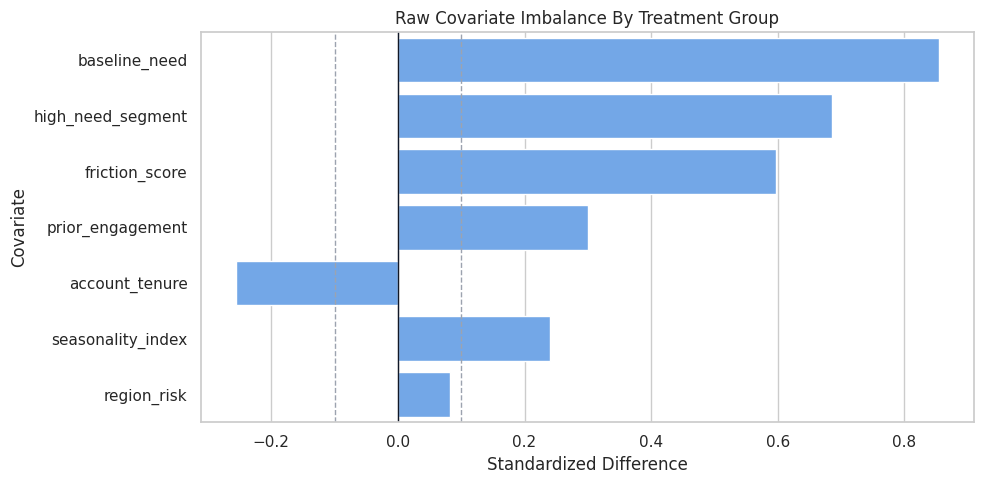

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=balance_table,
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Raw Covariate Imbalance By Treatment Group")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Covariate")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


DML is being used in a setting where adjustment is needed. The plot also warns us which variables should not be forgotten when defining controls and effect modifiers.

### Propensity Overlap

Overlap means that comparable users have some chance of being treated and some chance of not being treated. If the treatment probability is nearly zero or nearly one for many units, then the data has weak support for causal comparisons in those regions.

In this simulation we know the true propensity. In a real analysis we would only estimate it.

In [8]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(rows=("propensity", "size"), treatment_rate=("treatment", "mean"), true_cate_mean=("true_cate", "mean"))
    .reset_index()
)

propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "02_propensity_bucket_summary.csv", index=False)
display(propensity_summary)

,propensity_bucket,rows,treatment_rate,true_cate_mean
0,"(-0.001, 0.1]",119,0.0924,0.1198
1,"(0.1, 0.2]",315,0.1302,0.2304
2,"(0.2, 0.3]",372,0.3038,0.2734
3,"(0.3, 0.4]",401,0.3292,0.3806
4,"(0.4, 0.5]",373,0.4343,0.4356
5,"(0.5, 0.6]",348,0.5661,0.5428
6,"(0.6, 0.7]",323,0.6316,0.6212
7,"(0.7, 0.8]",336,0.7768,0.7091
8,"(0.8, 0.9]",303,0.8548,0.8456
9,"(0.9, 1.0]",110,0.9273,0.9950


Observations are spread across a range of treatment probabilities. The table also shows why treatment assignment and effect heterogeneity can interact: different propensity regions can have different average true CATE values.

#### Propensity Overlap Plot

The histogram below shows whether treated and untreated rows occupy similar propensity regions. Strong overlap means the residualized treatment signal has something to work with.

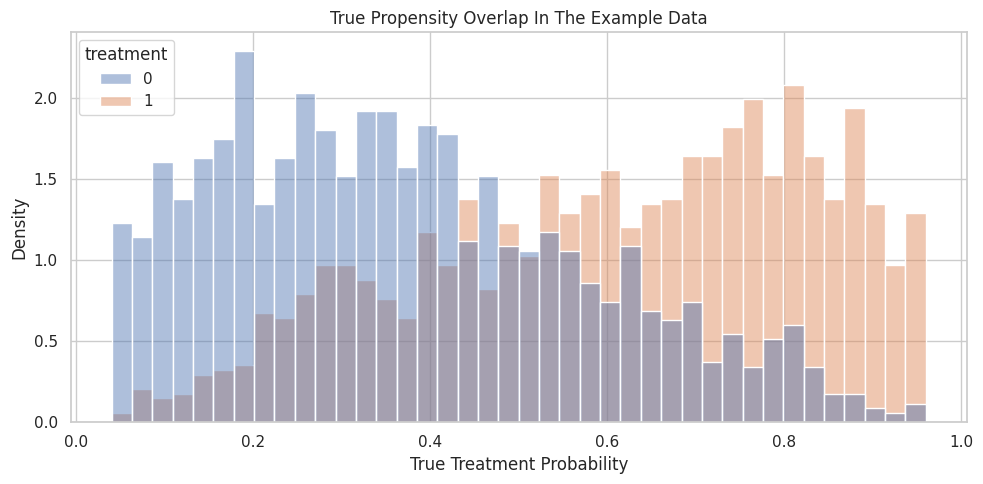

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap In The Example Data")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The two groups overlap enough for a clean worked example, but the distributions are not identical. That is exactly the zone where nuisance adjustment matters.



#### X and W Roles in EconML

EconML often separates covariates into two sets:

- `X`: effect modifiers. These are the variables used to describe how treatment effects vary.
- `W`: controls. These help remove confounding but are not the main variables used to report CATE variation.

A variable can be placed in `X` if you want the treatment effect to vary with it. A variable can be placed in `W` if it is mainly needed for adjustment.

For this lesson, all true CATE drivers are placed in `X`, while two pure confounders are placed in `W`.

In [10]:
effect_modifier_cols = ["baseline_need", "prior_engagement", "friction_score", "region_risk", "high_need_segment"]
control_cols = ["account_tenure", "seasonality_index"]
all_model_covariates = effect_modifier_cols + control_cols

role_table = pd.DataFrame(
    [
        {"column": col, "econml_role": "X", "why_included": "Allows the estimated treatment effect to vary with this feature."}
        for col in effect_modifier_cols
    ]
    + [
        {"column": col, "econml_role": "W", "why_included": "Adjusts for confounding in treatment and outcome nuisance models."}
        for col in control_cols
    ]
)

role_table.to_csv(TABLE_DIR / "02_x_w_role_table.csv", index=False)
display(role_table)


,column,econml_role,why_included
0,baseline_need,X,Allows the estimated treatment effect to vary with this feature.
1,prior_engagement,X,Allows the estimated treatment effect to vary with this feature.
2,friction_score,X,Allows the estimated treatment effect to vary with this feature.
3,region_risk,X,Allows the estimated treatment effect to vary with this feature.
4,high_need_segment,X,Allows the estimated treatment effect to vary with this feature.
5,account_tenure,W,Adjusts for confounding in treatment and outcome nuisance models.
6,seasonality_index,W,Adjusts for confounding in treatment and outcome nuisance models.


The role split is a modeling decision. If an important effect modifier is put only in `W`, EconML can adjust for it while leaving CATE variation along that dimension unreported.

#### Train and Test Split

The train set is used to fit nuisance models and treatment-effect models. The test set is held out for checking CATE recovery against known truth.

In real work, there is no true CATE column, so the test set would be used for diagnostics, robustness checks, and policy evaluation rather than oracle accuracy.

In [11]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)

train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_ate": train_df["true_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_ate": test_df["true_cate"].mean()},
    ]
)

split_summary.to_csv(TABLE_DIR / "02_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,true_ate
0,train,1950,0.4938,0.4903
1,test,1050,0.4943,0.5152


Stratifying by treatment keeps the train and test treatment rates similar. The true ATEs are also close, which helps make the tutorial comparison stable.

#### Prepare Modeling Matrices

The code below creates the arrays and data frames used by the manual DML steps and EconML. The important point is that oracle fields are excluded from model inputs.

- `Y_train` and `T_train` are the observed outcome and treatment.
- `X_train` contains effect modifiers.
- `W_train` contains controls.
- `nuisance_train` contains both `X` and `W` because nuisance models should use all observed pre-treatment covariates that help predict treatment or outcome.

In [12]:
Y_train = train_df["outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_test = test_df["outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()

X_train = train_df[effect_modifier_cols]
X_test = test_df[effect_modifier_cols]
W_train = train_df[control_cols]
W_test = test_df[control_cols]

nuisance_train = train_df[all_model_covariates]
nuisance_test = test_df[all_model_covariates]
true_cate_train = train_df["true_cate"].to_numpy()
true_cate_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    [
        {"object": "Y_train", "rows": Y_train.shape[0], "columns": 1, "meaning": "Observed outcome used for training."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment used for training."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "Effect modifiers for CATE estimation."},
        {"object": "W_train", "rows": W_train.shape[0], "columns": W_train.shape[1], "meaning": "Controls for nuisance adjustment."},
        {"object": "nuisance_train", "rows": nuisance_train.shape[0], "columns": nuisance_train.shape[1], "meaning": "All observed pre-treatment features used by nuisance models."},
    ]
)

matrix_summary.to_csv(TABLE_DIR / "02_model_matrix_summary.csv", index=False)
display(matrix_summary)


,object,rows,columns,meaning
0,Y_train,1950,1,Observed outcome used for training.
1,T_train,1950,1,Observed binary treatment used for training.
2,X_train,1950,5,Effect modifiers for CATE estimation.
3,W_train,1950,2,Controls for nuisance adjustment.
4,nuisance_train,1950,7,All observed pre-treatment features used by nuisance models.


The DML workflow has separate data roles even though many columns come from the same original table. Being explicit here prevents leakage and makes the EconML call easier to read.

### Nuisance Models

DML uses two nuisance models:

1. Outcome nuisance model: predicts `Y` from observed pre-treatment covariates.
2. Treatment nuisance model: predicts `T` from observed pre-treatment covariates.

These are called nuisance models because they are not the final causal answer. They are supporting models that remove predictable structure from outcome and treatment.

The next cell uses cross-fitting: each training row gets a prediction from a model that did not train on that row.

In [13]:
# Save the artifacts produced by the Nuisance Models section.
outcome_nuisance_model = GradientBoostingRegressor(random_state=RANDOM_SEED)
treatment_nuisance_model = GradientBoostingClassifier(random_state=RANDOM_SEED)

outcome_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
treatment_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

Y_hat_oof = cross_val_predict(
    outcome_nuisance_model,
    nuisance_train,
    Y_train,
    cv=outcome_cv,
    method="predict",
)
T_hat_oof = cross_val_predict(
    treatment_nuisance_model,
    nuisance_train,
    T_train,
    cv=treatment_cv,
    method="predict_proba",
)[:, 1]

nuisance_metrics = pd.DataFrame(
    [
        {
            "nuisance_model": "outcome E[Y | X, W]",
            "metric": "out_of_fold_rmse",
            "value": np.sqrt(mean_squared_error(Y_train, Y_hat_oof)),
        },
        {
            "nuisance_model": "treatment E[T | X, W]",
            "metric": "out_of_fold_auc",
            "value": roc_auc_score(T_train, T_hat_oof),
        },
        {
            "nuisance_model": "treatment E[T | X, W]",
            "metric": "out_of_fold_brier_score",
            "value": brier_score_loss(T_train, T_hat_oof),
        },
        {
            "nuisance_model": "treatment E[T | X, W]",
            "metric": "out_of_fold_log_loss",
            "value": log_loss(T_train, T_hat_oof),
        },
    ]
)

nuisance_metrics.to_csv(TABLE_DIR / "02_nuisance_cross_fit_metrics.csv", index=False)
display(nuisance_metrics)


,nuisance_model,metric,value
0,"outcome E[Y | X, W]",out_of_fold_rmse,0.9342
1,"treatment E[T | X, W]",out_of_fold_auc,0.7503
2,"treatment E[T | X, W]",out_of_fold_brier_score,0.2039
3,"treatment E[T | X, W]",out_of_fold_log_loss,0.5944


Nuisance models are judged by predictive quality, but good prediction alone is not the causal answer. Their job is to remove confounding-related predictability so the final residualized treatment variation is closer to as-if random variation.




## Reporting and Takeaways

### Cross-Fitting Fold Summary

Cross-fitting matters because using in-sample nuisance predictions can make residuals look artificially small. That can leak overfitting into the causal stage.

The next cell shows the fold sizes and treatment rates used by the treatment nuisance cross-fitting split.

In [14]:
fold_rows = []
for fold_id, (fold_train_idx, fold_holdout_idx) in enumerate(treatment_cv.split(nuisance_train, T_train), start=1):
    fold_rows.append(
        {
            "fold": fold_id,
            "fit_rows": len(fold_train_idx),
            "holdout_rows": len(fold_holdout_idx),
            "holdout_treatment_rate": T_train[fold_holdout_idx].mean(),
        }
    )

fold_summary = pd.DataFrame(fold_rows)
fold_summary.to_csv(TABLE_DIR / "02_cross_fitting_fold_summary.csv", index=False)
display(fold_summary)


,fold,fit_rows,holdout_rows,holdout_treatment_rate
0,1,1560,390,0.4923
1,2,1560,390,0.4923
2,3,1560,390,0.4949
3,4,1560,390,0.4949
4,5,1560,390,0.4949


Every row is held out once for nuisance prediction. Stratification keeps the treatment rate stable across folds, which is helpful when the treatment model estimates propensities.



### Residualize Outcome and Treatment

Residualization subtracts each nuisance prediction from the observed value:

- outcome residual: `Y - predicted_Y`
- treatment residual: `T - predicted_T`

The residualized treatment is especially important. It represents the part of treatment assignment not explained by the observed covariates.

In [15]:
Y_residual = Y_train - Y_hat_oof
T_residual = T_train - T_hat_oof

residualized_train = train_df.assign(
    outcome_hat_oof=Y_hat_oof,
    treatment_hat_oof=T_hat_oof,
    outcome_residual=Y_residual,
    treatment_residual=T_residual,
)

residual_summary = residualized_train[["outcome_residual", "treatment_residual", "treatment_hat_oof"]].describe().T.reset_index()
residual_summary = residual_summary.rename(columns={"index": "quantity"})
residual_summary.to_csv(TABLE_DIR / "02_residual_summary.csv", index=False)
display(residual_summary)


,quantity,count,mean,std,min,25%,50%,75%,max
0,outcome_residual,"1,950.0000",-0.0024,0.9344,-3.0014,-0.6472,-0.0190,0.6228,3.6873
1,treatment_residual,"1,950.0000",0.0021,0.4517,-0.9560,-0.3522,-0.0561,0.3679,0.9378
2,treatment_hat_oof,"1,950.0000",0.4917,0.2507,0.0360,0.2780,0.4804,0.7083,0.9708


Residuals are centered close to zero because the predictable part has been subtracted. The residualized treatment still has variation, which is essential; without residualized treatment variation, there is no local comparison left for estimating effects.



### Residualized Treatment Distribution

This plot checks whether residualized treatment variation remains after adjusting for covariates. Treated rows tend to have positive treatment residuals and untreated rows tend to have negative residuals, but the magnitude depends on the estimated propensity.

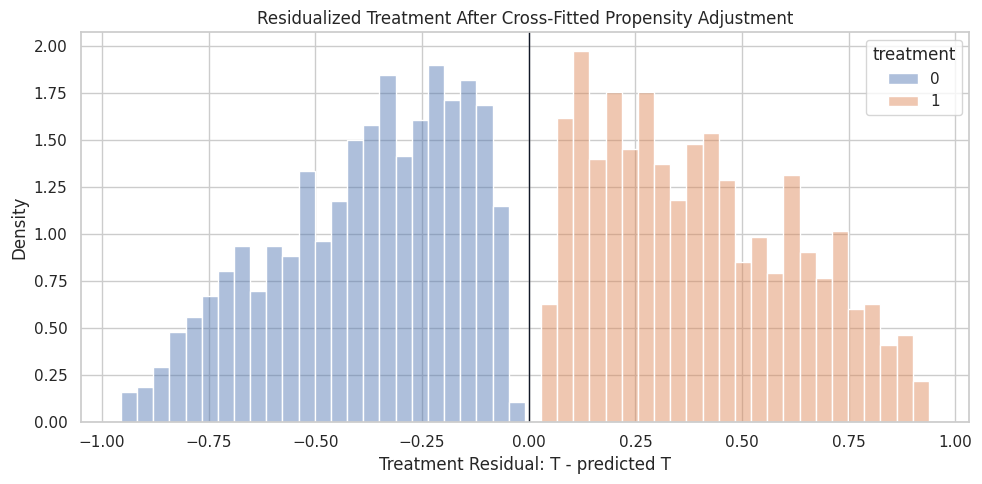

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=residualized_train,
    x="treatment_residual",
    hue="treatment",
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Residualized Treatment After Cross-Fitted Propensity Adjustment")
ax.set_xlabel("Treatment Residual: T - predicted T")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_residualized_treatment_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


DML is not comparing all treated rows to all untreated rows. It compares residualized deviations from expected treatment assignment, which reduces the role of observed confounding.



### Manual Residual-On-Residual ATE

A very simple DML-style ATE can be estimated by regressing outcome residuals on treatment residuals with no intercept. This serves a different role than the full CATE estimator yet. It is the cleanest way to see the partialling-out idea.

The final-stage model is:

`outcome_residual = ate * treatment_residual + final_stage_noise`

In [17]:
manual_ate_model = LinearRegression(fit_intercept=False)
manual_ate_model.fit(T_residual.reshape(-1, 1), Y_residual)
manual_dml_ate_train = float(manual_ate_model.coef_[0])

manual_ate_summary = pd.DataFrame(
    [
        {"method": "raw treated-control difference", "estimate": raw_difference, "target": "overall ATE", "truth_for_comparison": true_ate},
        {"method": "manual residual-on-residual DML", "estimate": manual_dml_ate_train, "target": "training-sample residualized ATE", "truth_for_comparison": train_df["true_cate"].mean()},
        {"method": "oracle true ATE", "estimate": true_ate, "target": "overall ATE", "truth_for_comparison": true_ate},
    ]
)
manual_ate_summary["estimate_minus_truth"] = manual_ate_summary["estimate"] - manual_ate_summary["truth_for_comparison"]
manual_ate_summary.to_csv(TABLE_DIR / "02_manual_dml_ate_summary.csv", index=False)
display(manual_ate_summary)


,method,estimate,target,truth_for_comparison,estimate_minus_truth
0,raw treated-control difference,1.2338,overall ATE,0.4990,0.7348
1,manual residual-on-residual DML,0.4820,training-sample residualized ATE,0.4903,-0.0084
2,oracle true ATE,0.4990,overall ATE,0.4990,0.0000


Residualization typically moves the estimate closer to the true effect than the raw comparison. It is still a simplified ATE-style calculation, so the next step lets the treatment effect vary with `X`.

### Partialling-Out Scatter

The scatter plot shows the final-stage ATE idea visually. Each point is a training row after removing the predicted outcome and predicted treatment parts.

The fitted line is the manual residual-on-residual ATE estimate.

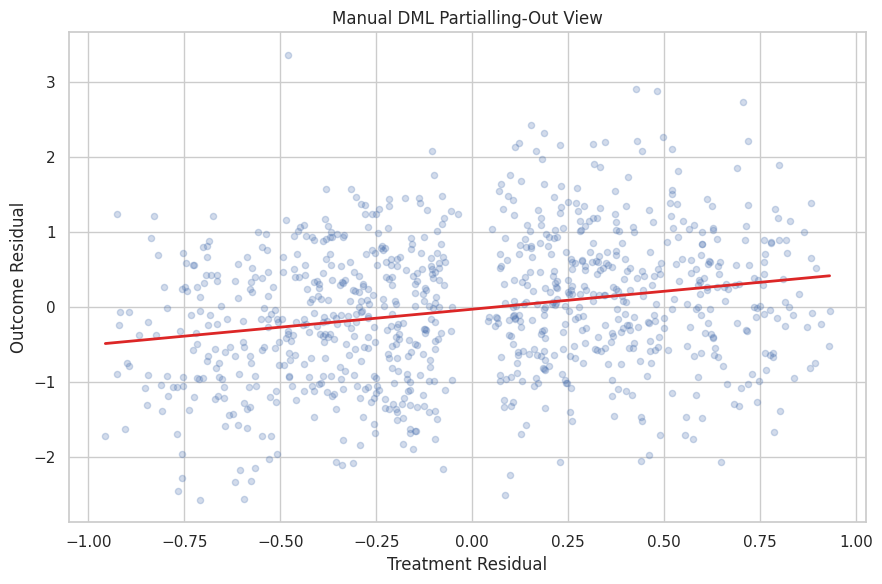

In [18]:
plot_sample = residualized_train.sample(n=900, random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=plot_sample,
    x="treatment_residual",
    y="outcome_residual",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "#dc2626", "linewidth": 2},
    ci=None,
    ax=ax,
)
ax.set_title("Manual DML Partialling-Out View")
ax.set_xlabel("Treatment Residual")
ax.set_ylabel("Outcome Residual")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_partialling_out_scatter.png", dpi=160, bbox_inches="tight")
plt.show()


The slope is estimated after both axes have been adjusted for observed covariates. The cloud is noisy because individual outcomes are noisy, but the residualized relationship is the signal DML uses.

#### Manual Linear CATE from Residualized Interactions

To estimate heterogeneous effects, we let the residualized treatment interact with the effect modifiers in `X`.

The final-stage model becomes:

`outcome_residual = treatment_residual * (intercept + b1 * X1 + b2 * X2 +...) + final_stage_noise`

This is the same broad idea behind `LinearDML`: use nuisance models to residualize, then use a final linear model to describe how the treatment effect changes with `X`.


In [19]:
# Fit or evaluate the model objects used in the Manual Linear CATE From Residualized Interactions section.
X_train_values = X_train.to_numpy()
manual_final_features = np.column_stack([T_residual, T_residual[:, None] * X_train_values])
manual_feature_names = ["cate_intercept"] + effect_modifier_cols

manual_cate_model = LinearRegression(fit_intercept=False)
manual_cate_model.fit(manual_final_features, Y_residual)
manual_cate_coefficients = np.ravel(manual_cate_model.coef_)

manual_cate_test = manual_cate_coefficients[0] + X_test.to_numpy() @ manual_cate_coefficients[1:]
manual_cate_train = manual_cate_coefficients[0] + X_train.to_numpy() @ manual_cate_coefficients[1:]

manual_cate_metrics = pd.DataFrame(
    [
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, manual_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, manual_cate_test)[0, 1]},
        {"metric": "test_estimated_ate", "value": manual_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": manual_cate_test.mean() - true_cate_test.mean()},
    ]
)

manual_cate_coefs = pd.DataFrame(
    {
        "term": manual_feature_names,
        "manual_dml_coefficient": manual_cate_coefficients,
        "true_structural_coefficient": [0.45, 0.28, 0.18, -0.22, -0.10, 0.24],
    }
)

manual_cate_metrics.to_csv(TABLE_DIR / "02_manual_linear_cate_metrics.csv", index=False)
manual_cate_coefs.to_csv(TABLE_DIR / "02_manual_linear_cate_coefficients.csv", index=False)

display(manual_cate_metrics)
display(manual_cate_coefs)


,metric,value
0,test_cate_rmse,0.0793
1,test_cate_correlation,0.9821
2,test_estimated_ate,0.4980
3,test_true_ate,0.5152
4,test_ate_error,-0.0172


,term,manual_dml_coefficient,true_structural_coefficient
0,cate_intercept,0.4984,0.4500
1,baseline_need,0.2807,0.2800
2,prior_engagement,0.1859,0.1800
3,friction_score,-0.2036,-0.2200
4,region_risk,-0.2567,-0.1000
5,high_need_segment,0.1940,0.2400


The manual CATE model can recover much of the true effect pattern because the true CATE was designed to be linear in `X`. The coefficient table connects the causal estimand to a concrete final-stage regression.

#### Fit EconML LinearDML

Now we let EconML perform the DML workflow directly. `LinearDML` will:

- fit nuisance models for outcome and treatment;
- use cross-fitting internally;
- residualize treatment and outcome;
- fit a final linear CATE model over `X`;
- return unit-level effect estimates through `.effect(X)`.

We use random forests as nuisance models to show that DML can combine flexible first-stage prediction with a simple final-stage CATE model.

In [20]:
# Fit or evaluate the model objects used in the Fit EconML LinearDML section.
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")

econml_outcome_model = RandomForestRegressor(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
econml_treatment_model = RandomForestClassifier(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

linear_dml = LinearDML(
    model_y=econml_outcome_model,
    model_t=econml_treatment_model,
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)

linear_dml.fit(Y_train, T_train, X=X_train, W=W_train)

econml_cate_train = np.ravel(linear_dml.effect(X_train))
econml_cate_test = np.ravel(linear_dml.effect(X_test))

linear_dml_summary = pd.DataFrame(
    [
        {"metric": "train_estimated_ate", "value": econml_cate_train.mean()},
        {"metric": "train_true_ate", "value": true_cate_train.mean()},
        {"metric": "test_estimated_ate", "value": econml_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": econml_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, econml_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, econml_cate_test)[0, 1]},
    ]
)

linear_dml_summary.to_csv(TABLE_DIR / "02_lineardml_summary.csv", index=False)
display(linear_dml_summary)


,metric,value
0,train_estimated_ate,0.5014
1,train_true_ate,0.4903
2,test_estimated_ate,0.5289
3,test_true_ate,0.5152
4,test_ate_error,0.0137
5,test_cate_rmse,0.0979
6,test_cate_correlation,0.9779


EconML produces unit-level CATE estimates and an average effect over any population we pass in. In this truth-known lesson, we can verify both average-effect accuracy and CATE ranking quality.



#### Compare Manual DML and EconML

The manual estimator and `LinearDML` use the same conceptual ingredients, but not exactly the same implementation details. This comparison is useful because it separates the idea of DML from the library implementation.

In [21]:
# Save the artifacts produced by the Compare Manual DML And EconML section.
model_comparison = pd.DataFrame(
    [
        {
            "method": "raw treated-control difference",
            "estimated_ate_on_test_population": raw_difference,
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": raw_difference - true_cate_test.mean(),
            "cate_rmse": np.nan,
            "cate_correlation": np.nan,
        },
        {
            "method": "manual linear DML",
            "estimated_ate_on_test_population": manual_cate_test.mean(),
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": manual_cate_test.mean() - true_cate_test.mean(),
            "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, manual_cate_test)),
            "cate_correlation": np.corrcoef(true_cate_test, manual_cate_test)[0, 1],
        },
        {
            "method": "EconML LinearDML",
            "estimated_ate_on_test_population": econml_cate_test.mean(),
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": econml_cate_test.mean() - true_cate_test.mean(),
            "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, econml_cate_test)),
            "cate_correlation": np.corrcoef(true_cate_test, econml_cate_test)[0, 1],
        },
    ]
)

model_comparison.to_csv(TABLE_DIR / "02_model_comparison.csv", index=False)
display(model_comparison)


,method,estimated_ate_on_test_population,true_ate_on_test_population,ate_error,cate_rmse,cate_correlation
0,raw treated-control difference,1.2338,0.5152,0.7186,NaN,NaN
1,manual linear DML,0.4980,0.5152,-0.0172,0.0793,0.9821
2,EconML LinearDML,0.5289,0.5152,0.0137,0.0979,0.9779


The raw comparison has no CATE diagnostics because it gives only one number. The DML-style methods give individual effect estimates, so we can evaluate both the average effect and how well the model recovers heterogeneity.

#### CATE Recovery Plot

A useful simulation diagnostic is estimated CATE versus true CATE. The 45-degree line represents perfect recovery. Points close to that line mean the model is learning the heterogeneous effect structure.

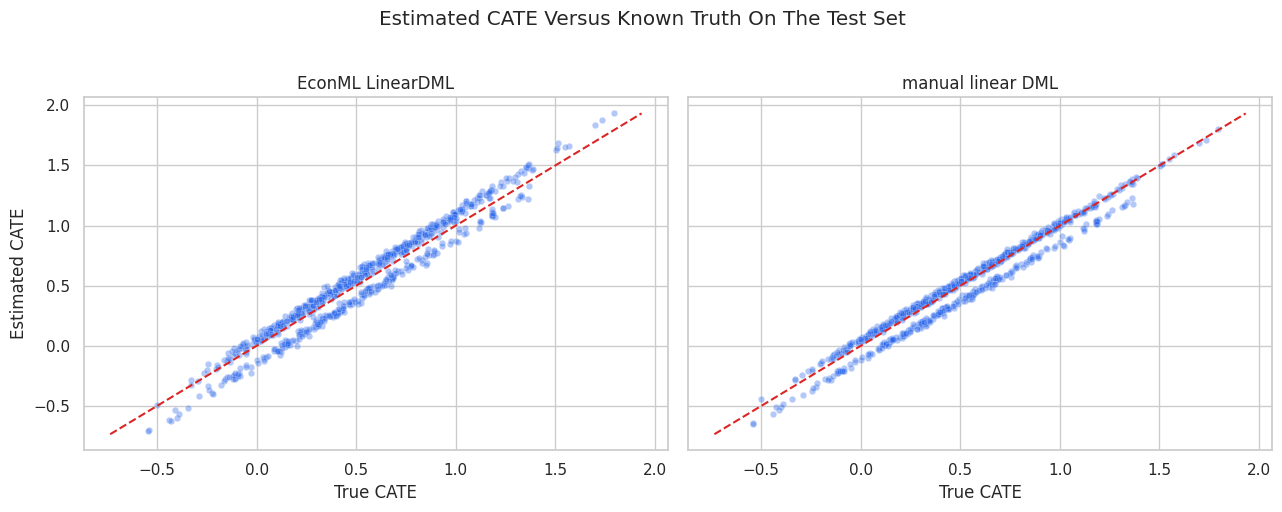

In [22]:
# Build and label the diagnostic visualization for the CATE Recovery Plot section.
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": manual_cate_test, "model": "manual linear DML"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": econml_cate_test, "model": "EconML LinearDML"}),
    ],
    ignore_index=True,
)

limits = [
    min(cate_plot_df["true_cate"].min(), cate_plot_df["estimated_cate"].min()),
    max(cate_plot_df["true_cate"].max(), cate_plot_df["estimated_cate"].max()),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (model_name, model_df) in zip(axes, cate_plot_df.groupby("model")):
    sns.scatterplot(
        data=model_df.sample(n=min(800, len(model_df)), random_state=RANDOM_SEED),
        x="true_cate",
        y="estimated_cate",
        alpha=0.35,
        s=22,
        color="#2563eb",
        ax=ax,
    )
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.set_title(model_name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")

plt.suptitle("Estimated CATE Versus Known Truth On The Test Set", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()


Both DML versions recover the broad ranking pattern when the final-stage functional form matches the true CATE. Scatter around the diagonal reflects finite sample noise, nuisance model error, and final-stage estimation error.



#### EconML Final-Stage Coefficients

Because `LinearDML` uses a linear final CATE model, we can inspect its coefficients. This is one of the reasons `LinearDML` is a good first EconML estimator: the CATE model is interpretable.

The coefficients are not the nuisance model coefficients. They describe how the treatment effect itself changes with `X`.

In [23]:
econml_intercept = float(np.ravel(linear_dml.intercept_)[0])
econml_coefs = np.ravel(linear_dml.coef_)

true_structural_coefs = pd.Series(
    [0.45, 0.28, 0.18, -0.22, -0.10, 0.24],
    index=["cate_intercept"] + effect_modifier_cols,
)

if len(econml_coefs) != len(effect_modifier_cols):
    raise ValueError(f"Expected {len(effect_modifier_cols)} LinearDML coefficients, found {len(econml_coefs)}")

econml_coef_table = pd.DataFrame(
    {
        "term": ["cate_intercept"] + effect_modifier_cols,
        "true_structural_coefficient": true_structural_coefs.values,
        "manual_linear_dml_coefficient": manual_cate_coefficients,
        "econml_lineardml_coefficient": [econml_intercept] + list(econml_coefs),
    }
)

econml_coef_table["econml_minus_truth"] = (
    econml_coef_table["econml_lineardml_coefficient"] - econml_coef_table["true_structural_coefficient"]
)

econml_coef_table.to_csv(TABLE_DIR / "02_lineardml_coefficients.csv", index=False)
display(econml_coef_table)


,term,true_structural_coefficient,manual_linear_dml_coefficient,econml_lineardml_coefficient,econml_minus_truth
0,cate_intercept,0.4500,0.4984,0.5315,0.0815
1,baseline_need,0.2800,0.2807,0.3114,0.0314
2,prior_engagement,0.1800,0.1859,0.1658,-0.0142
3,friction_score,-0.2200,-0.2036,-0.2503,-0.0303
4,region_risk,-0.1000,-0.2567,-0.3000,-0.2000
5,high_need_segment,0.2400,0.1940,0.2302,-0.0098


The final-stage coefficients are estimates of the treatment-effect equation, not estimates of the outcome equation. In this simulation, the signs should line up with the known CATE formula.



#### Segment-Level Recovery

Unit-level scatter plots are useful, but stakeholders often ask about segments. The next cell compares true and estimated CATE by high-need segment and region risk.

In [24]:
test_results = test_df.assign(
    manual_cate=manual_cate_test,
    econml_cate=econml_cate_test,
)

effect_segment_summary = (
    test_results.groupby(["high_need_segment", "region_risk"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        manual_cate=("manual_cate", "mean"),
        econml_cate=("econml_cate", "mean"),
        treatment_rate=("treatment", "mean"),
    )
    .reset_index()
)

effect_segment_summary["manual_error"] = effect_segment_summary["manual_cate"] - effect_segment_summary["true_cate"]
effect_segment_summary["econml_error"] = effect_segment_summary["econml_cate"] - effect_segment_summary["true_cate"]

effect_segment_summary.to_csv(TABLE_DIR / "02_segment_cate_recovery.csv", index=False)
display(effect_segment_summary)


,high_need_segment,region_risk,rows,true_cate,manual_cate,econml_cate,treatment_rate,manual_error,econml_error
0,0,0,473,0.3743,0.4185,0.4459,0.3594,0.0443,0.0717
1,0,1,228,0.2802,0.1651,0.1551,0.4123,-0.1150,-0.1250
2,1,0,239,0.8890,0.9030,0.9764,0.7280,0.0140,0.0874
3,1,1,110,0.7960,0.6493,0.6880,0.7364,-0.1467,-0.1081


Segment summaries translate CATE estimates into a format that is easier to explain. They also reveal whether the model is accurate only on average or whether it recovers important subgroup patterns.

#### Segment Recovery Plot

This plot puts the segment summary into a compact visual. Each marker is a segment average, not an individual row.

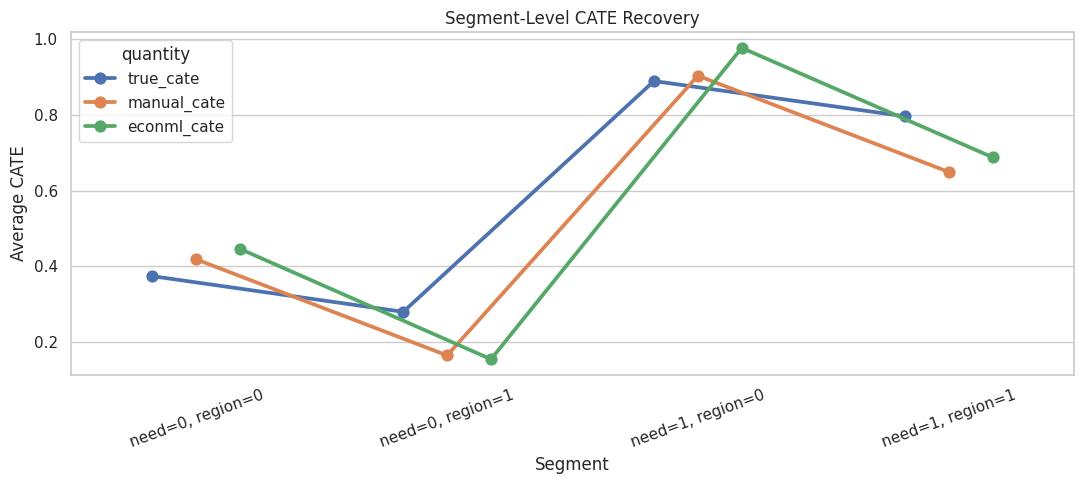

In [25]:
# Build and label the diagnostic visualization for the Segment Recovery Plot section.
segment_plot_df = effect_segment_summary.melt(
    id_vars=["high_need_segment", "region_risk", "rows"],
    value_vars=["true_cate", "manual_cate", "econml_cate"],
    var_name="quantity",
    value_name="average_cate",
)
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.pointplot(
    data=segment_plot_df,
    x="segment",
    y="average_cate",
    hue="quantity",
    dodge=0.35,
    errorbar=None,
    ax=ax,
)
ax.set_title("Segment-Level CATE Recovery")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_segment_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


The estimates are most useful when they preserve the ordering of segment benefits. Perfect segment accuracy is not required for the tutorial point; the key idea is that DML gives a structured way to estimate heterogeneity after adjustment.

#### CATE Decile Calibration

A common use case for CATE models is ranking units by expected benefit. If the model ranks well, higher predicted CATE deciles should also have higher average true CATE.

This check is only possible here because true CATE is known.

In [26]:
test_results = test_results.assign(
    econml_cate_decile=pd.qcut(test_results["econml_cate"], q=10, labels=False, duplicates="drop") + 1
)

decile_calibration = (
    test_results.groupby("econml_cate_decile", observed=True)
    .agg(
        rows=("outcome", "size"),
        estimated_cate=("econml_cate", "mean"),
        true_cate=("true_cate", "mean"),
        treatment_rate=("treatment", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)

decile_calibration.to_csv(TABLE_DIR / "02_econml_cate_decile_calibration.csv", index=False)
display(decile_calibration)


,econml_cate_decile,rows,estimated_cate,true_cate,treatment_rate,propensity_mean
0,1,105,-0.2062,-0.1230,0.3238,0.3395
1,2,105,0.0669,0.0941,0.3619,0.3767
2,3,105,0.2110,0.2197,0.3619,0.3863
3,4,105,0.3267,0.3247,0.4952,0.4251
4,5,105,0.4511,0.4408,0.4190,0.4379
5,6,105,0.5649,0.5532,0.5429,0.4977
6,7,105,0.7024,0.6575,0.5333,0.5186
7,8,105,0.8300,0.7851,0.5905,0.6236
8,9,105,1.0132,0.9571,0.5714,0.6208
9,10,105,1.3289,1.2424,0.7429,0.7487


A CATE model can be evaluated as a ranking model. The goal is to estimate one average effect and to identify which parts of the population appear to benefit more.

#### CATE Decile Calibration Plot

The plot checks whether predicted effect ranking agrees with known true effect ranking. A healthy curve rises as the predicted CATE decile increases.

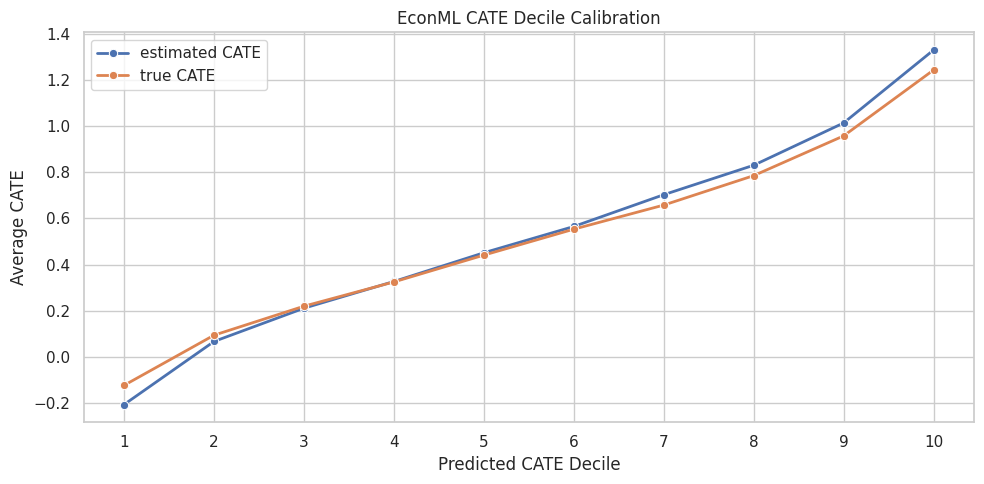

In [27]:
# Build and label the diagnostic visualization for the CATE Decile Calibration Plot section.
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=decile_calibration,
    x="econml_cate_decile",
    y="estimated_cate",
    marker="o",
    linewidth=2,
    label="estimated CATE",
    ax=ax,
)
sns.lineplot(
    data=decile_calibration,
    x="econml_cate_decile",
    y="true_cate",
    marker="o",
    linewidth=2,
    label="true CATE",
    ax=ax,
)
ax.set_title("EconML CATE Decile Calibration")
ax.set_xlabel("Predicted CATE Decile")
ax.set_ylabel("Average CATE")
ax.set_xticks(decile_calibration["econml_cate_decile"])
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_econml_cate_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()


The decile plot connects DML to decision-making. If predicted high-benefit groups also have high true benefit in simulation, the model is learning useful treatment-effect ranking structure.



#### What DML Assumes in Practice

DML is powerful, but it is not magic. It still relies on causal assumptions. The next table summarizes the main practical requirements behind the estimator.

| requirement | plain_language | practical_check |
| --- | --- | --- |
| Unconfoundedness after observed covariates | After conditioning on X and W, treatment assignment is as good as random. | Use domain knowledge; inspect balance; include all important pre-treatment confounders. |
| Overlap | Comparable units have a chance of being treated and untreated. | Inspect propensity distributions and avoid unsupported regions. |
| No post-treatment controls | Covariates used for adjustment must be measured before treatment. | Audit timestamps and feature definitions. |
| Reasonable nuisance models | Outcome and treatment models should capture the main predictive structure. | Use cross-fitted metrics, calibration checks, and sensitivity to model choices. |
| Appropriate final-stage CATE form | A linear final CATE model is only suitable when effect variation is reasonably linear in X. | Compare with forests or flexible learners when nonlinear heterogeneity is plausible. |


The estimator handles nuisance adjustment, but the analyst still owns the causal design. In real work, a DML result should be paired with design logic, overlap diagnostics, and robustness checks.



#### Practical DML Checklist

The final table turns the lesson into a reusable checklist. These are the questions to answer before presenting a DML estimate.

| step | question | why_it_matters |
| --- | --- | --- |
| 1 | Is the treatment clearly defined? | DML estimates the effect of a specific intervention, not a vague exposure. |
| 2 | Is the outcome measured after treatment? | Temporal order is necessary for a causal design. |
| 3 | Are all adjustment variables pre-treatment? | Post-treatment variables can block or distort causal pathways. |
| 4 | Which variables belong in X versus W? | X defines reported heterogeneity; W supports adjustment. |
| 5 | Is there enough overlap? | Without comparable treated and untreated units, the model extrapolates. |
| 6 | Do nuisance models have reasonable out-of-fold performance? | Poor nuisance models leave confounding structure in the residuals. |
| 7 | Do results persist across sensible model choices? | Robustness matters because flexible nuisance models can vary. |
| 8 | Are CATE estimates used with uncertainty and support in mind? | Treatment targeting should not overreact to noisy individual effects. |


DML is a workflow, more than one function call. The checklist is the bridge from a tutorial notebook to a credible applied analysis.

#### Summary

This lesson built double machine learning from the ground up.

The key takeaways are:

- raw treated-versus-control differences are biased when treatment assignment is confounded;
- DML estimates outcome and treatment nuisance functions first;
- cross-fitting gives each row nuisance predictions from models that did not train on that row;
- residualized treatment and residualized outcome isolate the final-stage causal signal;
- a simple residual-on-residual regression gives ATE intuition;
- residualized treatment interactions with `X` give CATE intuition;
- EconML's `LinearDML` packages this workflow into a reusable estimator;
- final CATE estimates should be checked for overlap, nuisance quality, segment recovery, and ranking behavior.

The next notebook can go deeper into `LinearDML` and `SparseLinearDML`, focusing on estimation details, coefficient reporting, and when sparse high-dimensional effect modification is useful.